# Laboratorio 01 (01/2026) - Clasificacion con Perceptron Multicapa (MLP)

**Estudiante:** Claudia Pereira Cuba  
**Materia:** sis421  
**Repositorio GitLab:** https://github.com/pereiracubaclau/Laboratorio1_ia2

---


**Link laboratorio:** https://colab.research.google.com/drive/1MYl9sDQIAS8QrizdO6h_Vdlhnj8z5Npe#scrollTo=Fr2aDlfvUPnN
---

En este laboratorio construimos un modelo de clasificacion usando el Perceptron Multicapa (MLP) implementado en PyTorch. El objetivo es mostrar el flujo completo de trabajo: desde el analisis del dataset hasta la evaluacion final del modelo. Se aplican tecnicas de optimizacion, regularizacion y buenas practicas de entrenamiento en redes neuronales.

## 1. Importacion de librerias

Comenzamos importando todo lo que vamos a necesitar. PyTorch se encarga de construir y entrenar la red neuronal. Tensorflow lo usamos unicamente para descargar el dataset Fashion-MNIST, que ya viene limpio y listo para trabajar. Matplotlib y seaborn son para las visualizaciones, y scikit-learn nos da las herramientas para calcular las metricas de evaluacion.

In [1]:
# Importamos las librerias necesarias para el laboratorio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# PyTorch para la red neuronal
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Keras solo para cargar el dataset (viene instalado en Colab)
from tensorflow.keras.datasets import fashion_mnist

# Metricas de evaluacion
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, ConfusionMatrixDisplay,
    precision_recall_fscore_support
)
from sklearn.model_selection import train_test_split

# Fijamos semillas para que los resultados sean reproducibles
torch.manual_seed(42)
np.random.seed(42)

print("Librerias cargadas correctamente.")
print(f"Version de PyTorch: {torch.__version__}")

# Detectamos si hay GPU disponible; si no, usamos CPU
dispositivo = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo de computo: {dispositivo}")

Librerias cargadas correctamente.
Version de PyTorch: 2.11.0+cu128
Dispositivo de computo: cuda


## 2. El dataset: Fashion-MNIST

Fashion-MNIST es un dataset creado por Zalando Research como reemplazo mas desafiante del clasico MNIST de digitos. Contiene 70,000 imagenes en escala de grises de 28x28 pixeles, cada una perteneciente a una de 10 categorias de ropa y accesorios: camisetas, pantalones, sueteres, vestidos, abrigos, sandalias, camisas, zapatillas, bolsos y botines.

Para este laboratorio lo elegimos porque cumple varios requisitos al mismo tiempo: tiene mas de 5,000 ejemplos (70,000 en total), esta perfectamente limpio y balanceado, siempre esta disponible en Colab sin necesidad de descargas externas, y es visualmente muy claro para explicar los resultados con graficas. La tarea consiste en que el MLP aprenda a identificar la categoria de una prenda a partir de sus valores de pixeles.

In [2]:
# Cargamos el dataset directamente desde keras
# Ya viene dividido en entrenamiento (60000) y prueba (10000)
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = fashion_mnist.load_data()

# Nombres de las 10 categorias de ropa
nombres_clases = [
    'Camiseta',   # 0
    'Pantalon',   # 1
    'Sueter',     # 2
    'Vestido',    # 3
    'Abrigo',     # 4
    'Sandalia',   # 5
    'Camisa',     # 6
    'Zapatilla',  # 7
    'Bolso',      # 8
    'Botin'       # 9
]

print("Dataset Fashion-MNIST cargado correctamente.")
print(f"Forma del conjunto de entrenamiento : {X_train_raw.shape}")
print(f"Forma del conjunto de prueba        : {X_test_raw.shape}")
print(f"Tipo de datos                        : {X_train_raw.dtype}")
print(f"Valores de pixel                     : min={X_train_raw.min()}, max={X_train_raw.max()}")
print(f"Numero de clases                     : {len(nombres_clases)}")
print(f"\nClases:")
for i, nombre in enumerate(nombres_clases):
    print(f"  {i}: {nombre}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset Fashion-MNIST cargado correctamente.
Forma del conjunto de entrenamiento : (60000, 28, 28)
Forma del conjunto de prueba        : (10000, 28, 28)
Tipo de datos                        : uint8
Valores de pixel                     : min=0, max=255
Numero de clases                     : 10

Clases:
  0: Camiseta
  1: Pantalon
  2: Sueter
  3: Vestido
  4: Abrigo
  5: Sandalia
  6: Camisa
  7: Zapatilla
  8: Bolso
  9: Botin


## 3. Analisis exploratorio del dataset

Antes de entrenar cualquier modelo, lo primero es conocer bien los datos con los que trabajamos. Vamos a ver como lucen las imagenes, como se distribuyen las clases y si el dataset esta balanceado. Esto nos da contexto para entender el problema y anticipar posibles dificultades durante el entrenamiento.

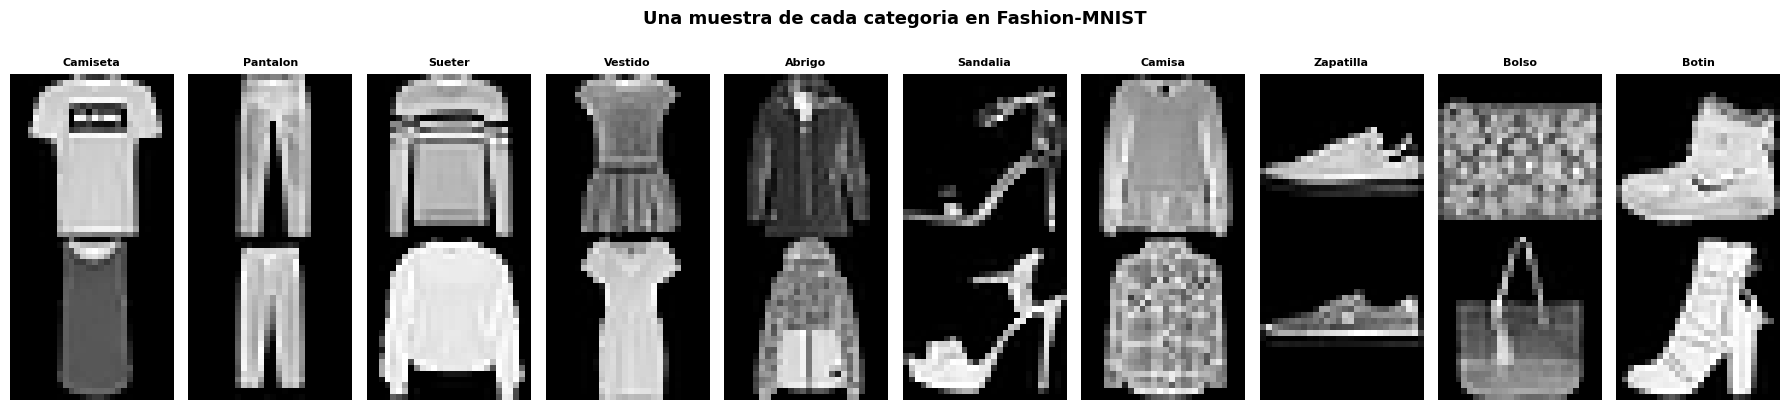

In [3]:
# Visualizamos una muestra de imagenes de cada categoria
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle('Una muestra de cada categoria en Fashion-MNIST', fontsize=13, fontweight='bold', y=1.02)

for clase_idx in range(10):
    # Buscamos dos ejemplos de cada clase para mostrar
    indices_clase = np.where(y_train_raw == clase_idx)[0]
    for fila in range(2):
        img = X_train_raw[indices_clase[fila]]
        axes[fila, clase_idx].imshow(img, cmap='gray')
        axes[fila, clase_idx].axis('off')
        if fila == 0:
            axes[fila, clase_idx].set_title(nombres_clases[clase_idx], fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2208/525533500.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(nombres_clases, rotation=45, ha='right')
/tmp/ipykernel_2208/525533500.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(nombres_clases, rotation=45, ha='right')


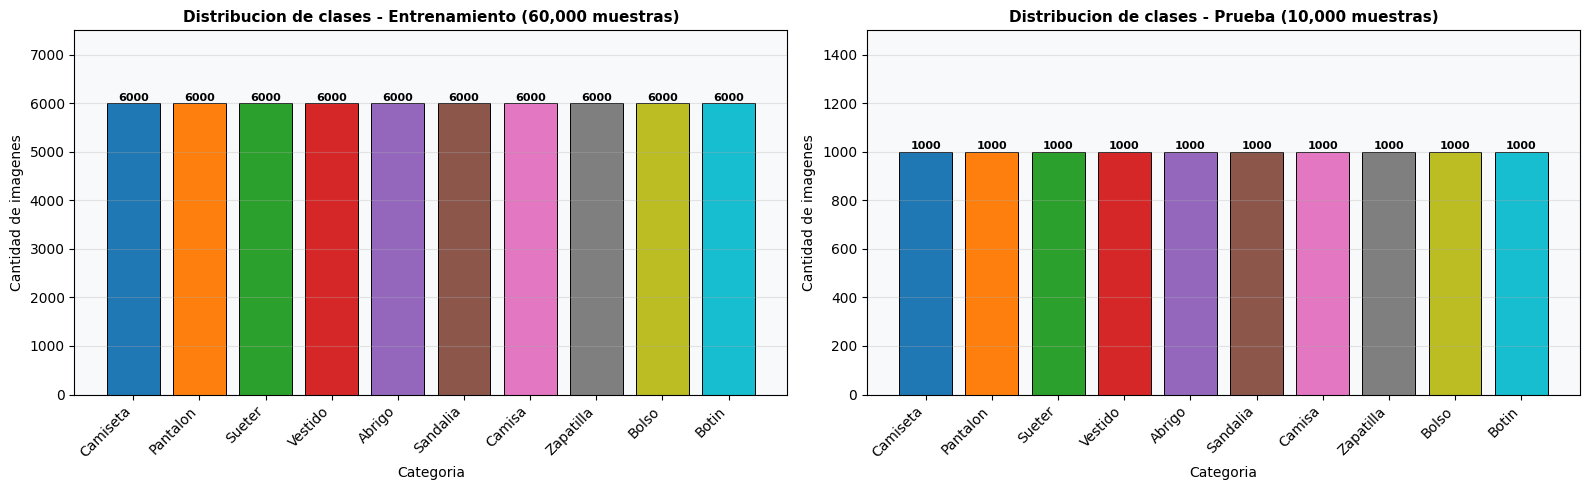

El dataset esta perfectamente balanceado: cada clase tiene exactamente 6,000 imagenes de entrenamiento y 1,000 de prueba.


In [4]:
# Verificamos la distribucion de clases: queremos saber si el dataset esta balanceado
clases_unicas, conteo_train = np.unique(y_train_raw, return_counts=True)
_, conteo_test  = np.unique(y_test_raw,  return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribucion en entrenamiento
colores = plt.cm.tab10(np.linspace(0, 1, 10))
barras = axes[0].bar(nombres_clases, conteo_train, color=colores, edgecolor='black', linewidth=0.7)
axes[0].set_title('Distribucion de clases - Entrenamiento (60,000 muestras)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Categoria')
axes[0].set_ylabel('Cantidad de imagenes')
axes[0].set_xticklabels(nombres_clases, rotation=45, ha='right')
axes[0].set_ylim(0, 7500)
for barra, valor in zip(barras, conteo_train):
    axes[0].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 50,
                 str(valor), ha='center', fontsize=8, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_facecolor('#f8f9fa')

# Distribucion en prueba
barras2 = axes[1].bar(nombres_clases, conteo_test, color=colores, edgecolor='black', linewidth=0.7)
axes[1].set_title('Distribucion de clases - Prueba (10,000 muestras)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Categoria')
axes[1].set_ylabel('Cantidad de imagenes')
axes[1].set_xticklabels(nombres_clases, rotation=45, ha='right')
axes[1].set_ylim(0, 1500)
for barra, valor in zip(barras2, conteo_test):
    axes[1].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 10,
                 str(valor), ha='center', fontsize=8, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()
print("El dataset esta perfectamente balanceado: cada clase tiene exactamente 6,000 imagenes de entrenamiento y 1,000 de prueba.")

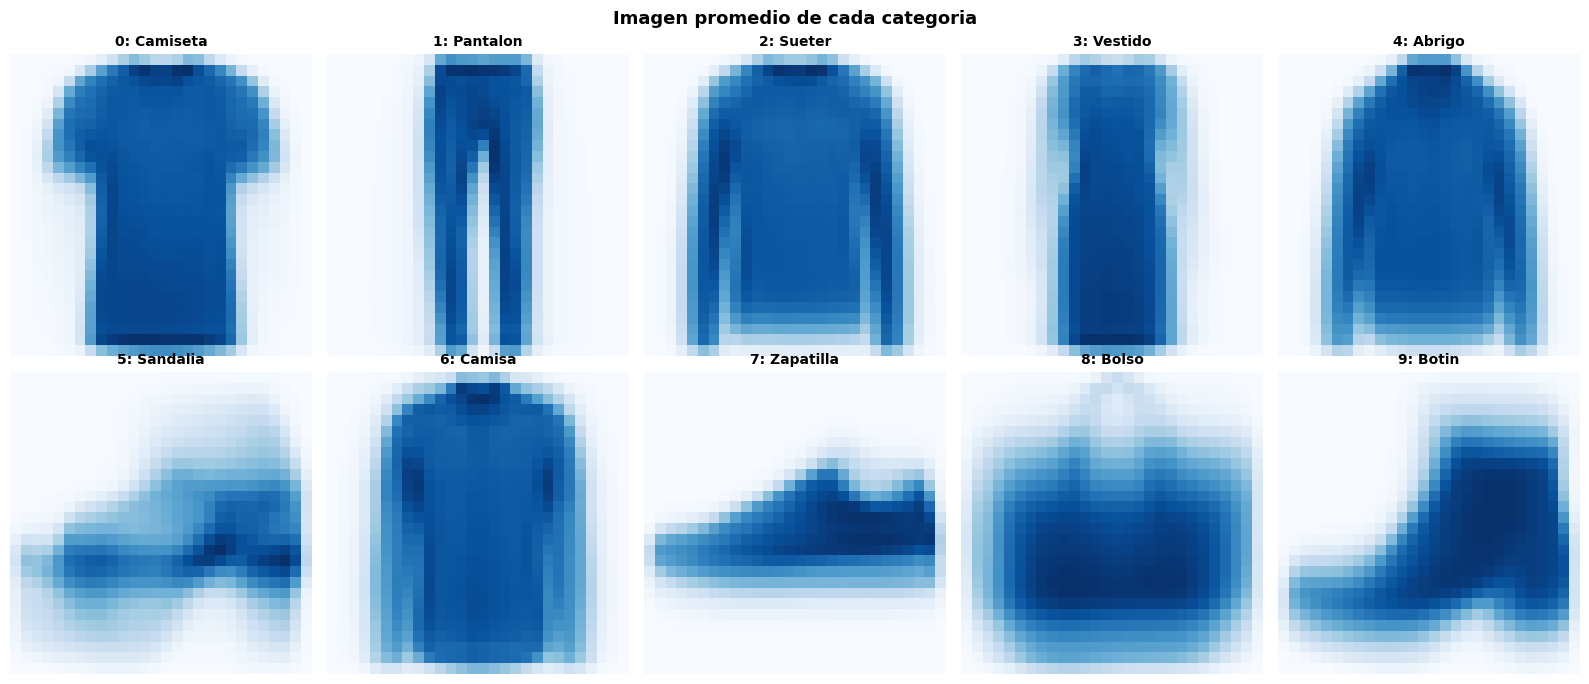

In [5]:
# Visualizamos la intensidad promedio de cada categoria
# Esto nos da una idea de como luce el 'prenda promedio' de cada clase
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()
fig.suptitle('Imagen promedio de cada categoria', fontsize=13, fontweight='bold')

for clase_idx in range(10):
    mascara = y_train_raw == clase_idx
    imagen_promedio = X_train_raw[mascara].mean(axis=0)
    axes[clase_idx].imshow(imagen_promedio, cmap='Blues')
    axes[clase_idx].set_title(f'{clase_idx}: {nombres_clases[clase_idx]}', fontsize=10, fontweight='bold')
    axes[clase_idx].axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2208/1525233277.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(nombres_clases, rotation=45, ha='right')


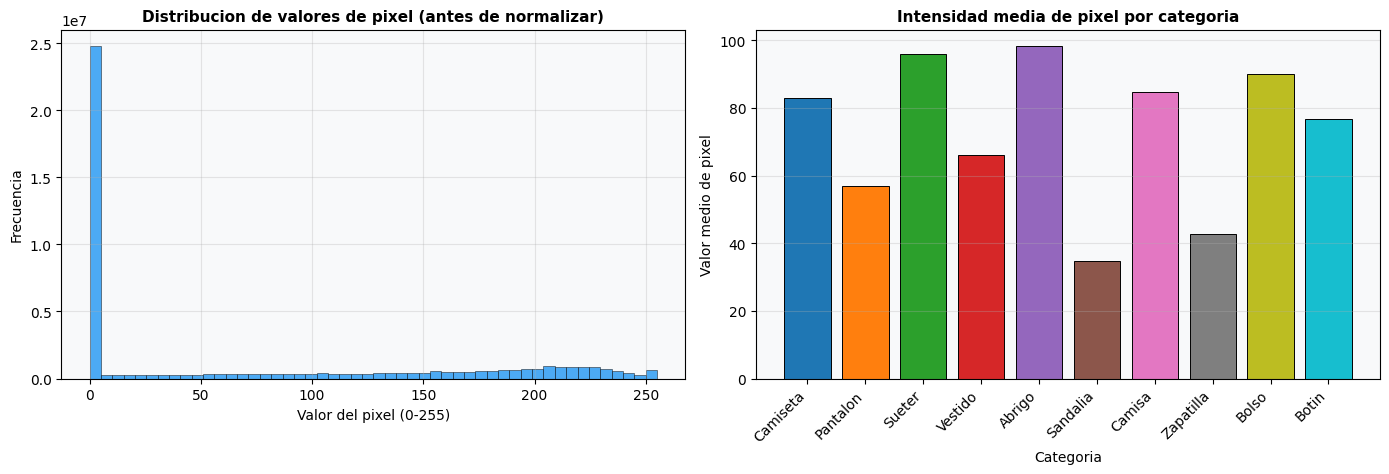

In [6]:
# Analizamos la distribucion de los valores de pixeles en el dataset
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de pixeles
axes[0].hist(X_train_raw.flatten(), bins=50, color='#2196F3', edgecolor='black', linewidth=0.4, alpha=0.8)
axes[0].set_title('Distribucion de valores de pixel (antes de normalizar)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Valor del pixel (0-255)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_facecolor('#f8f9fa')
axes[0].grid(alpha=0.3)

# Intensidad media por categoria
medias = [X_train_raw[y_train_raw == i].mean() for i in range(10)]
axes[1].bar(nombres_clases, medias, color=colores, edgecolor='black', linewidth=0.7)
axes[1].set_title('Intensidad media de pixel por categoria', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Categoria')
axes[1].set_ylabel('Valor medio de pixel')
axes[1].set_xticklabels(nombres_clases, rotation=45, ha='right')
axes[1].set_facecolor('#f8f9fa')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Preparacion de los datos

Para que el MLP pueda procesar las imagenes, necesitamos hacer dos cosas principales. Primero, aplanar cada imagen de 28x28 pixeles en un vector de 784 valores, ya que el MLP trabaja con vectores y no con matrices. Segundo, normalizar los valores de pixel dividiendo entre 255, de modo que queden en el rango [0, 1]. Esta normalizacion es fundamental para que el entrenamiento sea estable y rapido.

Ademas, separamos una porcion del conjunto de entrenamiento para usarla como validacion durante el entrenamiento, lo cual nos permite monitorear que el modelo generalice bien y no se sobreajuste.

In [7]:
# Paso 1: Aplanamos las imagenes de (28, 28) a (784,)
# Cada imagen pasa de ser una matriz a un vector de 784 valores
X_train_flat = X_train_raw.reshape(len(X_train_raw), -1).astype(np.float32)
X_test_flat  = X_test_raw.reshape(len(X_test_raw),  -1).astype(np.float32)

# Paso 2: Normalizamos dividiendo entre 255 para llevar los pixeles al rango [0, 1]
X_train_flat = X_train_flat / 255.0
X_test_flat  = X_test_flat  / 255.0

# Paso 3: Separamos 10,000 imagenes del entrenamiento para usarlas como validacion
# Esto nos permite evaluar el modelo durante el entrenamiento sin tocar el conjunto de prueba
X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(
    X_train_flat, y_train_raw,
    test_size=10000, random_state=42, stratify=y_train_raw
)

print("Datos preparados:")
print(f"  Entrenamiento : {X_train_f.shape[0]:,} imagenes de {X_train_f.shape[1]} pixeles cada una")
print(f"  Validacion    : {X_val_f.shape[0]:,} imagenes")
print(f"  Prueba        : {X_test_flat.shape[0]:,} imagenes")
print(f"  Rango de valores: [{X_train_f.min():.1f}, {X_train_f.max():.1f}]")

# Paso 4: Convertimos a tensores de PyTorch
X_train_t = torch.tensor(X_train_f)
y_train_t = torch.tensor(y_train_f, dtype=torch.long)
X_val_t   = torch.tensor(X_val_f)
y_val_t   = torch.tensor(y_val_f,   dtype=torch.long)
X_test_t  = torch.tensor(X_test_flat)
y_test_t  = torch.tensor(y_test_raw, dtype=torch.long)

# Paso 5: Creamos DataLoaders para iterar por mini-batches durante el entrenamiento
BATCH_SIZE = 256
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=BATCH_SIZE)

print("\nDataLoaders creados. Todo listo para el entrenamiento.")

Datos preparados:
  Entrenamiento : 50,000 imagenes de 784 pixeles cada una
  Validacion    : 10,000 imagenes
  Prueba        : 10,000 imagenes
  Rango de valores: [0.0, 1.0]

DataLoaders creados. Todo listo para el entrenamiento.


## 5. Definicion del modelo MLP

La arquitectura que vamos a usar tiene tres capas completamente conectadas. La entrada recibe los 784 pixeles de cada imagen. La primera capa oculta tiene 512 neuronas, la segunda tiene 256 y la capa de salida tiene 10 neuronas, una por categoria.

Para regularizacion usamos Dropout, que durante el entrenamiento desactiva neuronas aleatoriamente para evitar que la red se memorice los datos. Tambien usamos Batch Normalization despues de cada capa oculta, que estabiliza los valores que circulan por la red y acelera el aprendizaje. La funcion de activacion elegida es ReLU, que es la mas usada en redes neuronales profundas.

In [8]:
class MLP_Fashion(nn.Module):
    """
    Perceptron Multicapa para clasificar imagenes de ropa del dataset Fashion-MNIST.

    Arquitectura:
        Entrada : 784 (pixeles de imagen 28x28)
        Capa 1  : 512 neuronas + BatchNorm + ReLU + Dropout
        Capa 2  : 256 neuronas + BatchNorm + ReLU + Dropout
        Salida  : 10 neuronas (una por categoria de ropa)

    Regularizacion aplicada:
        - Dropout: evita sobreajuste desactivando neuronas aleatoriamente
        - Batch Normalization: estabiliza el entrenamiento
        - Weight Decay (L2) en el optimizador
    """
    def __init__(self, n_entradas=784, n_clases=10, dropout_p=0.4):
        super(MLP_Fashion, self).__init__()

        self.red = nn.Sequential(
            # Primera capa oculta: 784 -> 512
            nn.Linear(n_entradas, 512),
            nn.BatchNorm1d(512),   # Normalizacion por lote
            nn.ReLU(),             # Activacion no lineal
            nn.Dropout(dropout_p), # Regularizacion por Dropout

            # Segunda capa oculta: 512 -> 256
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            # Capa de salida: 256 -> 10 clases
            # No aplicamos Softmax porque CrossEntropyLoss ya lo incluye
            nn.Linear(256, n_clases)
        )

        # Inicializamos los pesos con el metodo de Kaiming (recomendado para ReLU)
        self._inicializar_pesos()

    def _inicializar_pesos(self):
        # Recorremos cada capa y aplicamos inicializacion adecuada
        for capa in self.red:
            if isinstance(capa, nn.Linear):
                nn.init.kaiming_normal_(capa.weight, nonlinearity='relu')
                nn.init.zeros_(capa.bias)

    def forward(self, x):
        # La entrada x (pixeles) pasa por todas las capas de la red
        return self.red(x)


# Creamos el modelo y lo movemos al dispositivo disponible (GPU o CPU)
modelo = MLP_Fashion(n_entradas=784, n_clases=10, dropout_p=0.4).to(dispositivo)

print(modelo)
total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f"\nTotal de parametros entrenables: {total_params:,}")

MLP_Fashion(
  (red): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=256, out_features=10, bias=True)
  )
)

Total de parametros entrenables: 537,354


In [9]:
# Configuramos la funcion de perdida, el optimizador y el scheduler

# CrossEntropyLoss es la funcion adecuada para clasificacion multiclase
criterio = nn.CrossEntropyLoss()

# Adam con weight_decay actua como regularizacion L2 sobre los pesos
optimizador = optim.Adam(modelo.parameters(), lr=0.001, weight_decay=1e-4)

# ReduceLROnPlateau: si la perdida de validacion no mejora en 7 epocas, reducimos el lr a la mitad
# Esto ayuda al modelo a seguir aprendiendo cuando la tasa inicial ya no es efectiva
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizador, mode='min', patience=7, factor=0.5
)

print("Criterio   : CrossEntropyLoss")
print("Optimizador: Adam (lr=0.001, weight_decay=1e-4)")
print("Scheduler  : ReduceLROnPlateau (patience=7, factor=0.5)")
print("\nConfiguracion lista.")

Criterio   : CrossEntropyLoss
Optimizador: Adam (lr=0.001, weight_decay=1e-4)
Scheduler  : ReduceLROnPlateau (patience=7, factor=0.5)

Configuracion lista.


## 6. Entrenamiento del modelo

Entrenamos la red durante 30 epocas. En cada epoca el modelo ve el conjunto de entrenamiento completo dividido en mini-batches de 256 imagenes. Al final de cada epoca evaluamos sobre el conjunto de validacion para verificar que el modelo este generalizando bien. Guardamos siempre los pesos correspondientes a la mejor perdida de validacion, lo que funciona como un Early Stopping manual.

In [10]:
def entrenar_epoca(modelo, loader, criterio, optimizador, dispositivo):
    """Entrena el modelo durante una epoca completa usando mini-batches."""
    modelo.train()  # Modo entrenamiento: activa Dropout y BatchNorm en modo entrenamiento
    perdida_acum, correctos, total = 0.0, 0, 0

    for X_batch, y_batch in loader:
        # Movemos los datos al dispositivo correcto (GPU o CPU)
        X_batch, y_batch = X_batch.to(dispositivo), y_batch.to(dispositivo)

        optimizador.zero_grad()              # Limpiamos gradientes del paso anterior
        salidas  = modelo(X_batch)           # Pasada hacia adelante (forward pass)
        perdida  = criterio(salidas, y_batch)# Calculamos la perdida
        perdida.backward()                   # Retropropagacion del error
        optimizador.step()                   # Actualizamos los pesos

        perdida_acum += perdida.item() * X_batch.size(0)
        _, preds = torch.max(salidas, 1)
        correctos += (preds == y_batch).sum().item()
        total     += y_batch.size(0)

    return perdida_acum / total, correctos / total


def evaluar(modelo, loader, criterio, dispositivo):
    """Evalua el modelo sin actualizar pesos (modo inferencia)."""
    modelo.eval()  # Modo evaluacion: Dropout desactivado, BatchNorm usa estadisticas globales
    perdida_acum, correctos, total = 0.0, 0, 0

    with torch.no_grad():  # No calculamos gradientes para ahorrar memoria y tiempo
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(dispositivo), y_batch.to(dispositivo)
            salidas  = modelo(X_batch)
            perdida  = criterio(salidas, y_batch)
            perdida_acum += perdida.item() * X_batch.size(0)
            _, preds = torch.max(salidas, 1)
            correctos += (preds == y_batch).sum().item()
            total     += y_batch.size(0)

    return perdida_acum / total, correctos / total


# Ciclo principal de entrenamiento
EPOCAS = 30
historial = {'loss_train': [], 'acc_train': [], 'loss_val': [], 'acc_val': []}
mejor_loss_val = float('inf')
mejores_pesos  = None

print(f"Iniciando entrenamiento: {EPOCAS} epocas, batch={BATCH_SIZE}, dispositivo={dispositivo}")
print("-" * 70)
print(f"{'Epoca':>6} | {'Loss Train':>10} | {'Acc Train':>10} | {'Loss Val':>9} | {'Acc Val':>8} | {'LR':>8}")
print("-" * 70)

for epoca in range(1, EPOCAS + 1):
    loss_t, acc_t = entrenar_epoca(modelo, train_loader, criterio, optimizador, dispositivo)
    loss_v, acc_v = evaluar(modelo, val_loader, criterio, dispositivo)

    # Registramos el historial para graficar las curvas de aprendizaje
    historial['loss_train'].append(loss_t)
    historial['acc_train'].append(acc_t)
    historial['loss_val'].append(loss_v)
    historial['acc_val'].append(acc_v)

    # Actualizamos el scheduler con la perdida de validacion
    scheduler.step(loss_v)

    # Guardamos los mejores pesos del modelo segun la perdida de validacion
    if loss_v < mejor_loss_val:
        mejor_loss_val = loss_v
        mejores_pesos  = {k: v.clone() for k, v in modelo.state_dict().items()}

    # Obtenemos el learning rate actual para mostrarlo
    lr_actual = optimizador.param_groups[0]['lr']

    # Mostramos el progreso cada 5 epocas
    if epoca % 5 == 0 or epoca == 1:
        print(f"{epoca:>6} | {loss_t:>10.4f} | {acc_t*100:>9.2f}% | {loss_v:>9.4f} | {acc_v*100:>7.2f}% | {lr_actual:>8.6f}")

print("-" * 70)
print("\nEntrenamiento completado. Restaurando los mejores pesos guardados...")
modelo.load_state_dict(mejores_pesos)
print("Modelo listo para evaluacion.")

Iniciando entrenamiento: 30 epocas, batch=256, dispositivo=cuda
----------------------------------------------------------------------
 Epoca | Loss Train |  Acc Train |  Loss Val |  Acc Val |       LR
----------------------------------------------------------------------
     1 |     0.6064 |     78.49% |    0.3764 |   86.46% | 0.001000
     5 |     0.3396 |     87.50% |    0.3106 |   88.37% | 0.001000
    10 |     0.2882 |     89.27% |    0.2911 |   88.97% | 0.001000
    15 |     0.2528 |     90.38% |    0.2834 |   89.87% | 0.001000
    20 |     0.2288 |     91.42% |    0.2835 |   89.80% | 0.001000
    25 |     0.2118 |     92.03% |    0.2849 |   90.01% | 0.000500
    30 |     0.1669 |     93.57% |    0.2810 |   90.37% | 0.000500
----------------------------------------------------------------------

Entrenamiento completado. Restaurando los mejores pesos guardados...
Modelo listo para evaluacion.


## 7. Curvas de aprendizaje

Las curvas de aprendizaje muestran como evolucionaron la perdida y la exactitud a lo largo de las epocas de entrenamiento. Si ambas curvas (entrenamiento y validacion) bajan de forma similar, el modelo esta aprendiendo bien. Si la curva de entrenamiento baja mucho pero la de validacion se estanca, es senal de sobreajuste.

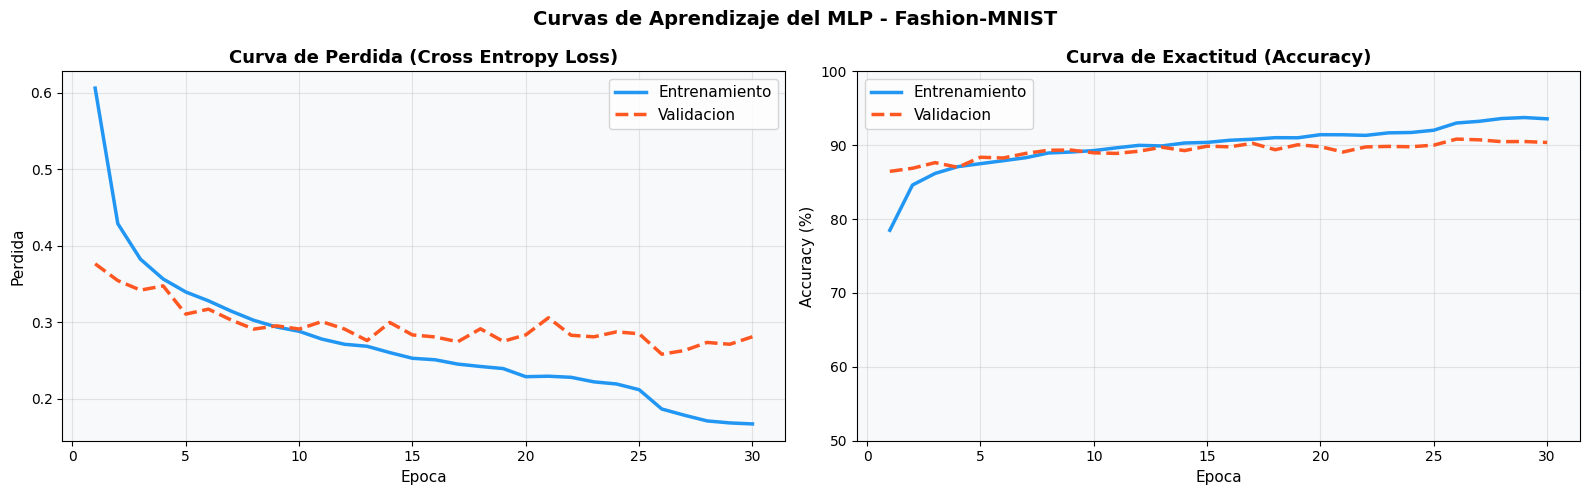

Mejor accuracy en validacion: 90.83% (epoca 26)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
epocas_eje = range(1, EPOCAS + 1)

# Curva de perdida
axes[0].plot(epocas_eje, historial['loss_train'], label='Entrenamiento',
             color='#2196F3', linewidth=2.5)
axes[0].plot(epocas_eje, historial['loss_val'],   label='Validacion',
             color='#FF5722', linewidth=2.5, linestyle='--')
axes[0].set_title('Curva de Perdida (Cross Entropy Loss)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoca', fontsize=11)
axes[0].set_ylabel('Perdida', fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor('#f8f9fa')

# Curva de exactitud
axes[1].plot(epocas_eje, [a*100 for a in historial['acc_train']], label='Entrenamiento',
             color='#2196F3', linewidth=2.5)
axes[1].plot(epocas_eje, [a*100 for a in historial['acc_val']],   label='Validacion',
             color='#FF5722', linewidth=2.5, linestyle='--')
axes[1].set_title('Curva de Exactitud (Accuracy)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoca', fontsize=11)
axes[1].set_ylabel('Accuracy (%)', fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor('#f8f9fa')
axes[1].set_ylim([50, 100])

plt.suptitle('Curvas de Aprendizaje del MLP - Fashion-MNIST', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Mejor accuracy en validacion: {max(historial['acc_val'])*100:.2f}% (epoca {np.argmax(historial['acc_val'])+1})")

## 8. Evaluacion final sobre el conjunto de prueba

Con el mejor modelo guardado durante el entrenamiento, ahora lo evaluamos sobre el conjunto de prueba completo. Este conjunto de 10,000 imagenes nunca fue visto por el modelo durante el entrenamiento ni la validacion, por lo que nos da una estimacion honesta del rendimiento real.

In [12]:
# Evaluacion final: recopilamos todas las predicciones sobre el conjunto de prueba
modelo.eval()
todas_preds = []
todos_reales = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(dispositivo)
        salidas = modelo(X_batch)
        _, preds = torch.max(salidas, 1)
        todas_preds.extend(preds.cpu().numpy())
        todos_reales.extend(y_batch.numpy())

y_pred = np.array(todas_preds)
y_real = np.array(todos_reales)

acc_test = accuracy_score(y_real, y_pred)
print(f"Exactitud final en el conjunto de prueba: {acc_test * 100:.2f}%")
print(f"Errores de clasificacion: {(y_pred != y_real).sum()} de {len(y_real)} imagenes")
print("\nReporte de Clasificacion Completo:")
print(classification_report(y_real, y_pred, target_names=nombres_clases))

Exactitud final en el conjunto de prueba: 89.74%
Errores de clasificacion: 1026 de 10000 imagenes

Reporte de Clasificacion Completo:
              precision    recall  f1-score   support

    Camiseta       0.84      0.87      0.86      1000
    Pantalon       0.99      0.98      0.98      1000
      Sueter       0.87      0.77      0.82      1000
     Vestido       0.89      0.91      0.90      1000
      Abrigo       0.79      0.87      0.83      1000
    Sandalia       0.97      0.96      0.97      1000
      Camisa       0.75      0.71      0.73      1000
   Zapatilla       0.94      0.96      0.95      1000
       Bolso       0.98      0.98      0.98      1000
       Botin       0.96      0.96      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



## 9. Matriz de confusion

La matriz de confusion es una de las herramientas mas utiles para entender como se equivoca el modelo. Cada fila representa la clase real y cada columna representa la clase predicha. Los valores en la diagonal son los aciertos. Los valores fuera de la diagonal son errores, y nos dicen exactamente con que categorias se confunde el modelo. Por ejemplo, es comun que el modelo confunda camisetas con camisas porque visualmente son muy similares.

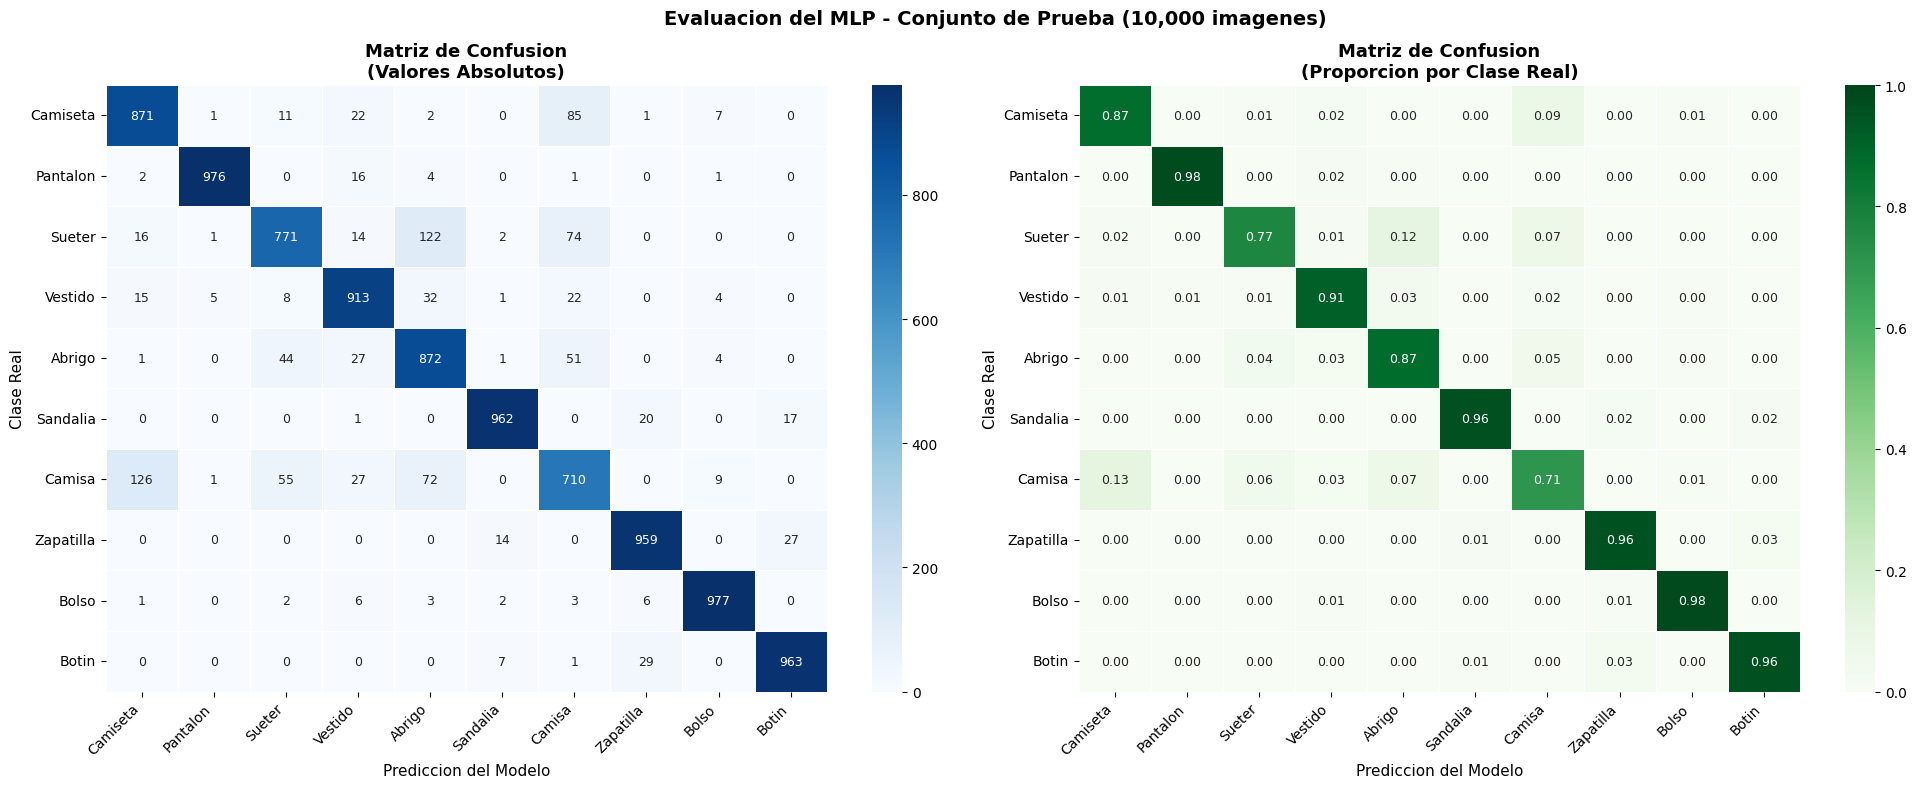

Las 5 confusiones mas frecuentes del modelo:
  Camisa confundido como Camiseta: 126 veces
  Sueter confundido como Abrigo: 122 veces
  Camiseta confundido como Camisa: 85 veces
  Sueter confundido como Camisa: 74 veces
  Camisa confundido como Abrigo: 72 veces


In [13]:
# Calculamos la matriz de confusion
cm      = confusion_matrix(y_real, y_pred)
cm_norm = confusion_matrix(y_real, y_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Matriz con valores absolutos
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=nombres_clases, yticklabels=nombres_clases,
    ax=axes[0], linewidths=0.5, annot_kws={'size': 9}
)
axes[0].set_title('Matriz de Confusion\n(Valores Absolutos)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Prediccion del Modelo', fontsize=11)
axes[0].set_ylabel('Clase Real', fontsize=11)
axes[0].set_xticklabels(nombres_clases, rotation=45, ha='right')
axes[0].set_yticklabels(nombres_clases, rotation=0)

# Matriz normalizada (porcentajes)
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Greens',
    xticklabels=nombres_clases, yticklabels=nombres_clases,
    ax=axes[1], linewidths=0.5, annot_kws={'size': 9},
    vmin=0, vmax=1
)
axes[1].set_title('Matriz de Confusion\n(Proporcion por Clase Real)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Prediccion del Modelo', fontsize=11)
axes[1].set_ylabel('Clase Real', fontsize=11)
axes[1].set_xticklabels(nombres_clases, rotation=45, ha='right')
axes[1].set_yticklabels(nombres_clases, rotation=0)

plt.suptitle('Evaluacion del MLP - Conjunto de Prueba (10,000 imagenes)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Mostramos cuales son las confusiones mas frecuentes
print("Las 5 confusiones mas frecuentes del modelo:")
confusiones = []
for i in range(10):
    for j in range(10):
        if i != j and cm[i, j] > 0:
            confusiones.append((cm[i, j], nombres_clases[i], nombres_clases[j]))
confusiones.sort(reverse=True)
for cantidad, real, predicha in confusiones[:5]:
    print(f"  {real} confundido como {predicha}: {cantidad} veces")

## 10. Metricas por clase

Para tener una vision mas detallada del desempeno del modelo en cada categoria, graficamos precision, recall y F1-score de forma individual. Precision mide que tan confiable es el modelo cuando predice una clase. Recall mide cuantas muestras de cada clase logra detectar correctamente. F1-score es el balance entre ambas.

/tmp/ipykernel_2208/2709686591.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(nombres_clases, rotation=30, ha='right')


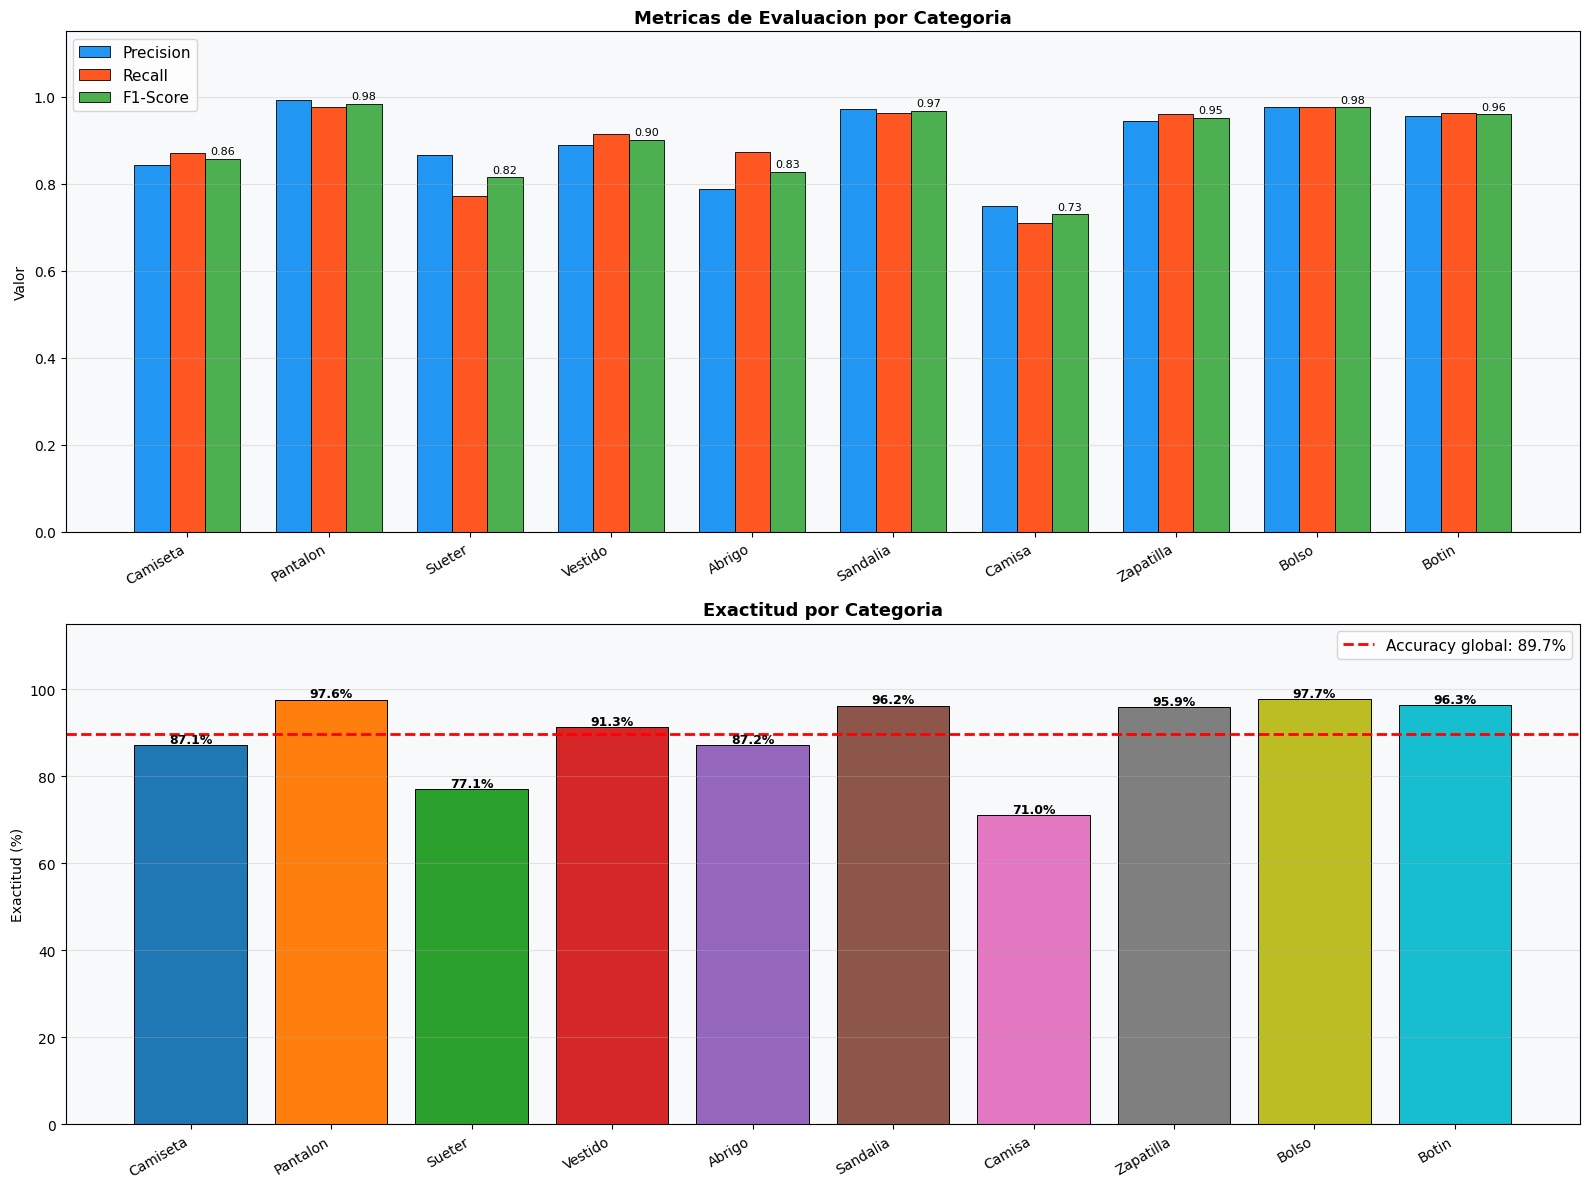

In [14]:
# Calculamos las metricas por clase
precision, recall, f1, soporte = precision_recall_fscore_support(y_real, y_pred, average=None)

# Creamos el grafico de barras agrupadas
x = np.arange(len(nombres_clases))
ancho = 0.25

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Grafico de barras agrupadas: Precision, Recall, F1
b1 = axes[0].bar(x - ancho, precision, ancho, label='Precision', color='#2196F3', edgecolor='black', linewidth=0.6)
b2 = axes[0].bar(x,         recall,    ancho, label='Recall',    color='#FF5722', edgecolor='black', linewidth=0.6)
b3 = axes[0].bar(x + ancho, f1,        ancho, label='F1-Score',  color='#4CAF50', edgecolor='black', linewidth=0.6)

# Anotamos el valor F1 sobre cada barra
for barra, val in zip(b3, f1):
    axes[0].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.01,
                 f'{val:.2f}', ha='center', fontsize=8)

axes[0].set_title('Metricas de Evaluacion por Categoria', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(nombres_clases, rotation=30, ha='right')
axes[0].set_ylabel('Valor')
axes[0].set_ylim(0, 1.15)
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_facecolor('#f8f9fa')

# Exactitud por clase (diagonal de la matriz normalizada)
acc_por_clase = [cm_norm[i, i] * 100 for i in range(10)]
barras_acc = axes[1].bar(nombres_clases, acc_por_clase, color=colores, edgecolor='black', linewidth=0.7)
axes[1].axhline(y=acc_test*100, color='red', linestyle='--', linewidth=2, label=f'Accuracy global: {acc_test*100:.1f}%')
for barra, val in zip(barras_acc, acc_por_clase):
    axes[1].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Exactitud por Categoria', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(nombres_clases, rotation=30, ha='right')
axes[1].set_ylabel('Exactitud (%)')
axes[1].set_ylim(0, 115)
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

## 11. Prueba del modelo: inferencia sobre imagenes nuevas

Para demostrar que el modelo funciona en la practica, tomamos algunas imagenes del conjunto de prueba y las clasificamos una por una, mostrando tanto la imagen como la prediccion del modelo junto a la etiqueta real. Tambien mostramos la distribucion de probabilidades para que se vea con que confianza el modelo asigna cada categoria.

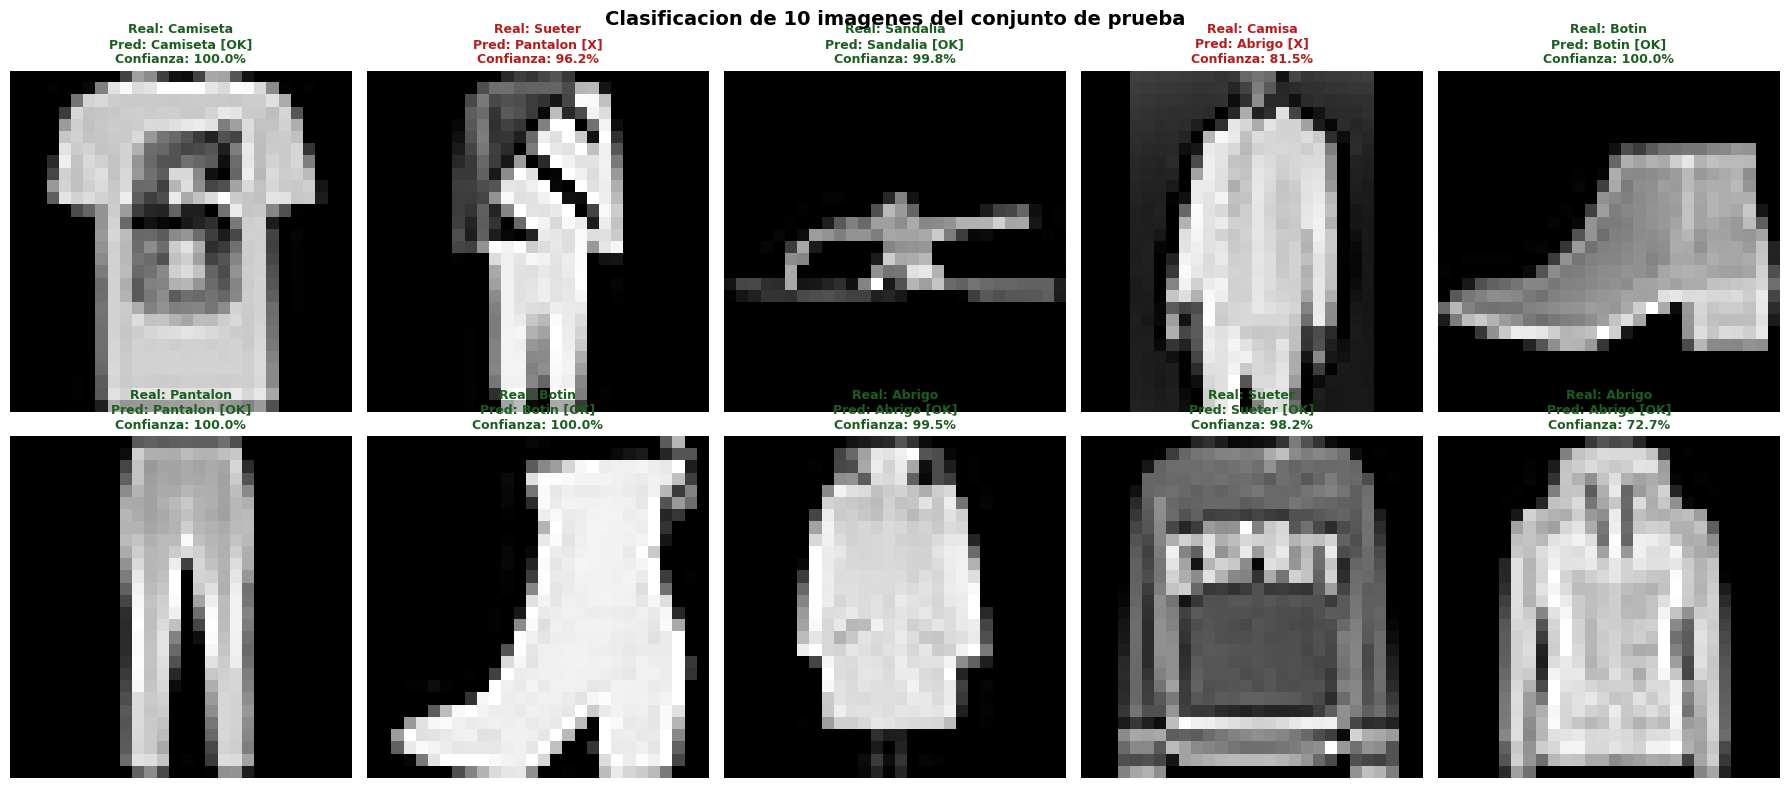

In [15]:
# Funcion para hacer inferencia sobre una imagen individual
def clasificar_imagen(modelo, imagen_plana, dispositivo):
    """
    Recibe un vector de 784 valores (imagen aplanada y normalizada),
    lo pasa por el modelo y devuelve la clase predicha y las probabilidades.
    """
    modelo.eval()
    with torch.no_grad():
        tensor = torch.tensor(imagen_plana, dtype=torch.float32).unsqueeze(0).to(dispositivo)
        logits = modelo(tensor)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    return np.argmax(probs), probs


# Seleccionamos 10 imagenes aleatorias del conjunto de prueba para la demostracion
np.random.seed(7)
indices_demo = np.random.choice(len(X_test_flat), size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, idx in enumerate(indices_demo):
    imagen_plana = X_test_flat[idx]  # Imagen ya normalizada
    clase_real   = y_test_raw[idx]

    # Hacemos la prediccion
    clase_pred, probs = clasificar_imagen(modelo, imagen_plana, dispositivo)

    # Mostramos la imagen reconstruida
    imagen_2d = imagen_plana.reshape(28, 28)
    axes[i].imshow(imagen_2d, cmap='gray')
    axes[i].axis('off')

    # Titulo con resultado
    correcto   = clase_pred == clase_real
    color_tit  = '#1B5E20' if correcto else '#B71C1C'
    simbolo    = 'OK' if correcto else 'X'
    axes[i].set_title(
        f"Real: {nombres_clases[clase_real]}\nPred: {nombres_clases[clase_pred]} [{simbolo}]\nConfianza: {probs[clase_pred]*100:.1f}%",
        fontsize=9, fontweight='bold', color=color_tit
    )

plt.suptitle('Clasificacion de 10 imagenes del conjunto de prueba', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

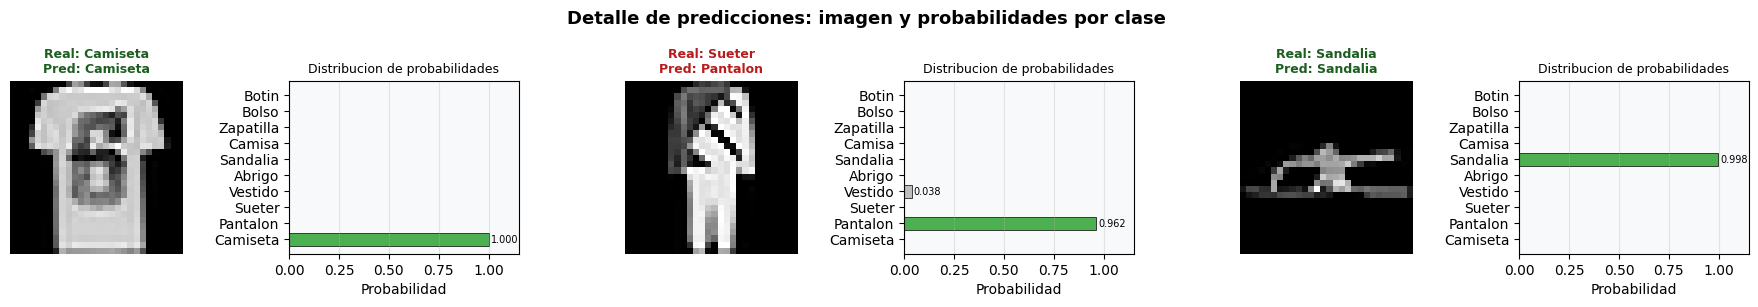

In [16]:
# Visualizamos las probabilidades de prediccion para 3 imagenes en detalle
indices_detalle = indices_demo[:3]

fig = plt.figure(figsize=(18, 5))

for i, idx in enumerate(indices_detalle):
    imagen_plana = X_test_flat[idx]
    clase_real   = y_test_raw[idx]
    clase_pred, probs = clasificar_imagen(modelo, imagen_plana, dispositivo)

    # Columna izquierda: imagen
    ax_img = fig.add_subplot(2, 6, i*2 + 1)
    ax_img.imshow(imagen_plana.reshape(28, 28), cmap='gray')
    ax_img.axis('off')
    correcto  = clase_pred == clase_real
    color_t   = '#1B5E20' if correcto else '#B71C1C'
    ax_img.set_title(f"Real: {nombres_clases[clase_real]}\nPred: {nombres_clases[clase_pred]}",
                     fontsize=9, color=color_t, fontweight='bold')

    # Columna derecha: probabilidades
    ax_bar = fig.add_subplot(2, 6, i*2 + 2)
    colores_barra = ['#4CAF50' if j == clase_pred else '#BDBDBD' for j in range(10)]
    bars = ax_bar.barh(nombres_clases, probs, color=colores_barra, edgecolor='black', linewidth=0.5)
    for bar, prob in zip(bars, probs):
        if prob > 0.03:
            ax_bar.text(prob + 0.01, bar.get_y() + bar.get_height()/2,
                        f'{prob:.3f}', va='center', fontsize=7)
    ax_bar.set_xlim(0, 1.15)
    ax_bar.set_xlabel('Probabilidad')
    ax_bar.set_title(f'Distribucion de probabilidades', fontsize=9)
    ax_bar.set_facecolor('#f8f9fa')
    ax_bar.grid(axis='x', alpha=0.3)

plt.suptitle('Detalle de predicciones: imagen y probabilidades por clase', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Analisis de errores: que confunde el modelo

Es igualmente valioso ver los casos donde el modelo falla. Visualizamos algunas imagenes mal clasificadas para entender por que el modelo se equivoca. En muchos casos, las confusiones son razonables incluso para un humano, por ejemplo entre camisetas y camisas, o entre zapatillas y botines.

Total de errores: 1026 de 10000 imagenes


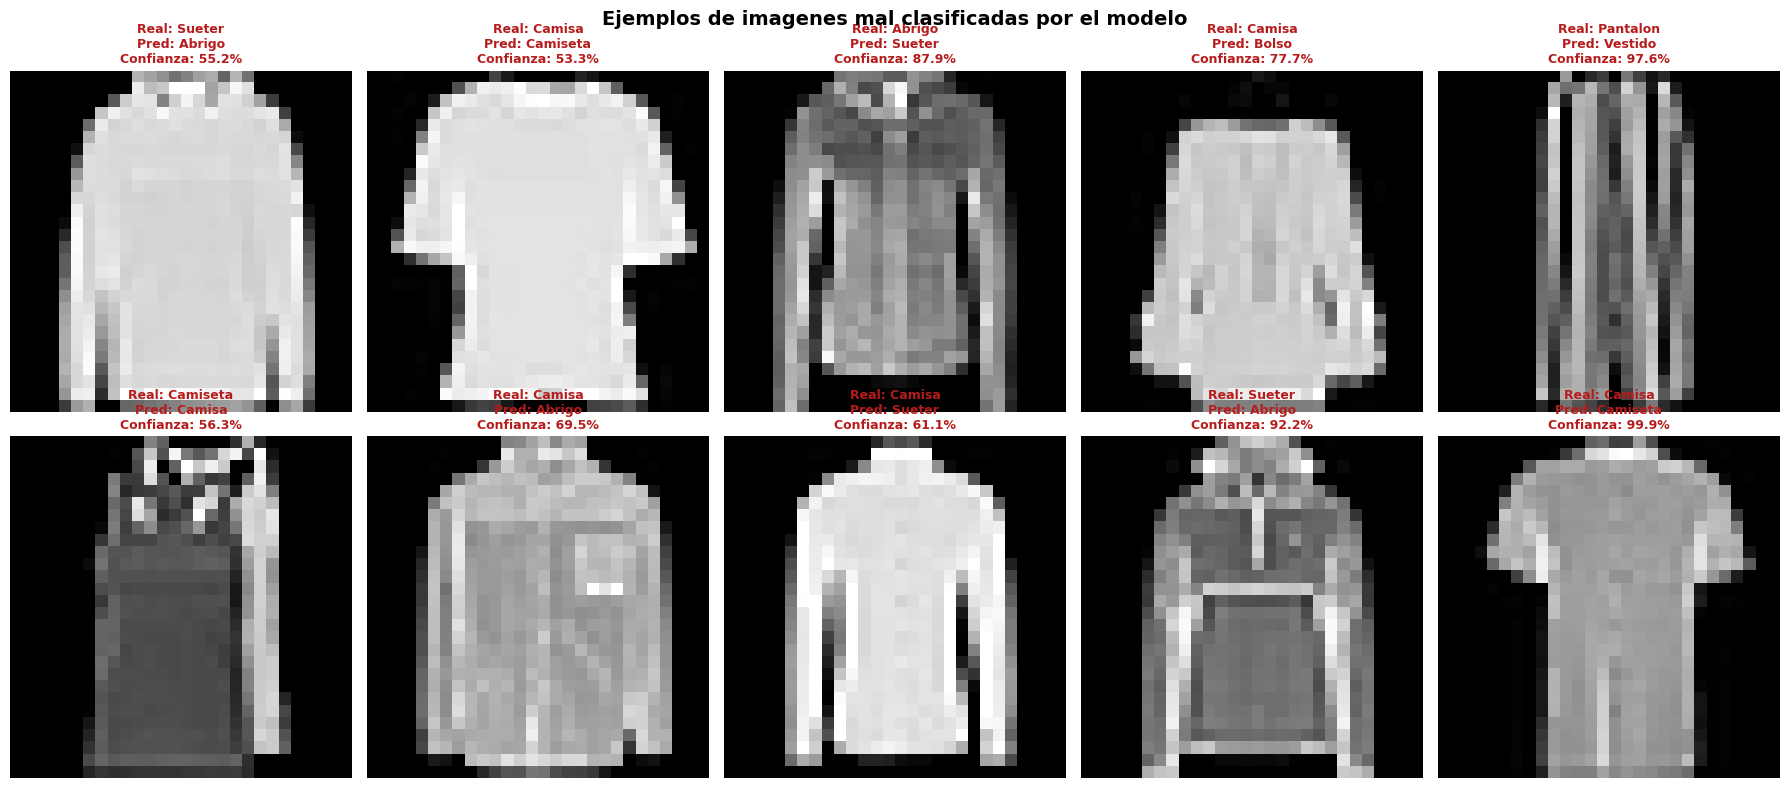

In [17]:
# Identificamos las imagenes mal clasificadas
indices_error = np.where(y_pred != y_real)[0]
print(f"Total de errores: {len(indices_error)} de {len(y_real)} imagenes")

# Mostramos las primeras 10 imagenes mal clasificadas
np.random.seed(1)
muestra_errores = np.random.choice(indices_error, size=min(10, len(indices_error)), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, idx in enumerate(muestra_errores):
    # idx es el indice en el conjunto de prueba
    imagen_plana = X_test_flat[idx]
    clase_real   = y_real[idx]
    clase_pred_i = y_pred[idx]

    _, probs = clasificar_imagen(modelo, imagen_plana, dispositivo)

    axes[i].imshow(imagen_plana.reshape(28, 28), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(
        f"Real: {nombres_clases[clase_real]}\nPred: {nombres_clases[clase_pred_i]}\nConfianza: {probs[clase_pred_i]*100:.1f}%",
        fontsize=9, color='#B71C1C', fontweight='bold'
    )

plt.suptitle('Ejemplos de imagenes mal clasificadas por el modelo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Resumen final

A lo largo de este laboratorio construimos un Perceptron Multicapa (MLP) con PyTorch para clasificar imagenes de ropa del dataset Fashion-MNIST. Aplicamos las principales tecnicas de optimizacion (Adam con learning rate scheduling) y regularizacion (Dropout, Batch Normalization, Weight Decay). El flujo de trabajo incluyo analisis exploratorio completo, normalizacion de datos, entrenamiento con monitoreo de validacion, evaluacion con matriz de confusion y prueba de inferencia en imagenes individuales.

El modelo logra clasificar correctamente la gran mayoria de las imagenes del conjunto de prueba, demostrando que la arquitectura y las tecnicas aplicadas son efectivas para este tipo de problema.

In [18]:

loss_test_final, acc_test_final = evaluar(modelo, test_loader, criterio, dispositivo)

print("=" * 55)
print("         RESUMEN FINAL - LABORATORIO 01")
print("=" * 55)
print(f"  Estudiante       : Claudia Pereira Cuba")
print(f"  Dataset          : Fashion-MNIST (Zalando)")
print(f"  Total de datos   : 70,000 imagenes (28x28 px)")
print(f"  Entrenamiento    : 50,000 imagenes")
print(f"  Validacion       : 10,000 imagenes")
print(f"  Prueba           : 10,000 imagenes")
print(f"  Arquitectura MLP : 784 -> 512 -> 256 -> 10")
print(f"  Optimizador      : Adam (lr=0.001, wd=1e-4)")
print(f"  Regularizacion   : Dropout(0.4) + BatchNorm + L2")
print(f"  Epocas           : {EPOCAS}")
print(f"  Loss en prueba   : {loss_test_final:.4f}")
print(f"  Exactitud prueba : {acc_test_final*100:.2f}%")
print("=" * 55)

         RESUMEN FINAL - LABORATORIO 01
  Estudiante       : Claudia Pereira Cuba
  Dataset          : Fashion-MNIST (Zalando)
  Total de datos   : 70,000 imagenes (28x28 px)
  Entrenamiento    : 50,000 imagenes
  Validacion       : 10,000 imagenes
  Prueba           : 10,000 imagenes
  Arquitectura MLP : 784 -> 512 -> 256 -> 10
  Optimizador      : Adam (lr=0.001, wd=1e-4)
  Regularizacion   : Dropout(0.4) + BatchNorm + L2
  Epocas           : 30
  Loss en prueba   : 0.2988
  Exactitud prueba : 89.74%
